# Real-Time Credit Card Fraud Detection System

**Live Pakistan – Machine Learning Internship, Month-Long Track, Week 2 of 4**

**Dataset:** Credit Card Fraud Detection (ULB Machine Learning Group) — [Kaggle link](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

**Goal :** Out of 284,807 transactions, only about 492 are fraud (roughly 0.17%).
That is a needle-in-a-haystack problem. A lazy model can say "everything is genuine" and still be
99.8% accurate — while catching **zero** fraud. This notebook is built to avoid that trap. We will:

1. Understand *why* accuracy is a bad metric here.
2. Try several ways of handling the imbalance and compare them honestly.
3. Train both supervised models (that learn from labels) and an unsupervised model (that learns
   what "normal" looks like and flags anything weird).
4. Pick a decision threshold using business cost, not the default 0.5.
5. Explain *why* the model flags a transaction (SHAP).
6. Check if the model's performance decays over time (drift).
7. (Stretch) Simulate a live transaction stream.
8. Save everything so it can be reused later.

> **Before running:** download `creditcard.csv` from the Kaggle link above and place it in the
> same folder as this notebook (or update `DATA_PATH` in the next section).


## 1. Project Setup

Here we import every library the notebook needs.

If any of these are missing, install them first, e.g.:
```
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost shap joblib
```


In [1]:
# ------------------------------------------------------------------
# Core data handling
# ------------------------------------------------------------------
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# Plotting
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# Preprocessing & model selection
# ------------------------------------------------------------------
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold, train_test_split

# ------------------------------------------------------------------
# Models
# ------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed - will fall back to a GradientBoostingClassifier instead.")
    from sklearn.ensemble import GradientBoostingClassifier

# ------------------------------------------------------------------
# Imbalance handling
# ------------------------------------------------------------------
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek

# ------------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------------
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report
)

# ------------------------------------------------------------------
# Explainability
# ------------------------------------------------------------------
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap not installed - will fall back to permutation importance instead.")
    from sklearn.inspection import permutation_importance

# ------------------------------------------------------------------
# Saving the final model
# ------------------------------------------------------------------
import joblib

# ------------------------------------------------------------------
# Misc
# ------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42          # fixed seed so results are reproducible every time we re-run this notebook
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All libraries loaded successfully.")


All libraries loaded successfully.


In [2]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

## 2. Load and Understand the Data

We now load the dataset and look at it from a few angles:
- How many rows/columns does it have, and are there missing values?
- Are there duplicate rows (the same transaction recorded twice)?
- How imbalanced is the "fraud" vs "genuine" split, really?
- Why does that imbalance make plain "accuracy" a useless scorecard?


In [3]:
# Update this path if your CSV is somewhere else
DATA_PATH = "creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head()


Shape of dataset (rows, columns): (284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Quick health check: data types and missing values
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum().sum(), "total missing values in the whole dataset")


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

**Explanation:** The `V1` to `V28` columns are already anonymized/scrambled numeric
features (produced using a technique called PCA) — we don't know exactly what real-world
information they represent, but the model can still learn patterns from them. Only `Time`
(seconds since the first transaction) and `Amount` (transaction value) are in their original,
human-readable form. `Class` is what we want to predict: `1` = fraud, `0` = genuine.

In [5]:
# ------------------------------------------------------------------
# Check for duplicate transactions
# ------------------------------------------------------------------
num_duplicates = df.duplicated().sum()
print(f"Number of exact duplicate rows found: {num_duplicates}")

# Duplicates can quietly inflate our metrics, because the exact same transaction
# could end up in both the training set and the test set, letting the model
# "cheat" by memorizing it instead of truly learning. So we drop them.
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")


Number of exact duplicate rows found: 1081
Shape after removing duplicates: (283726, 31)


Raw counts:
Class
0    283253
1       473
Name: count, dtype: int64

Percentages:
Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64


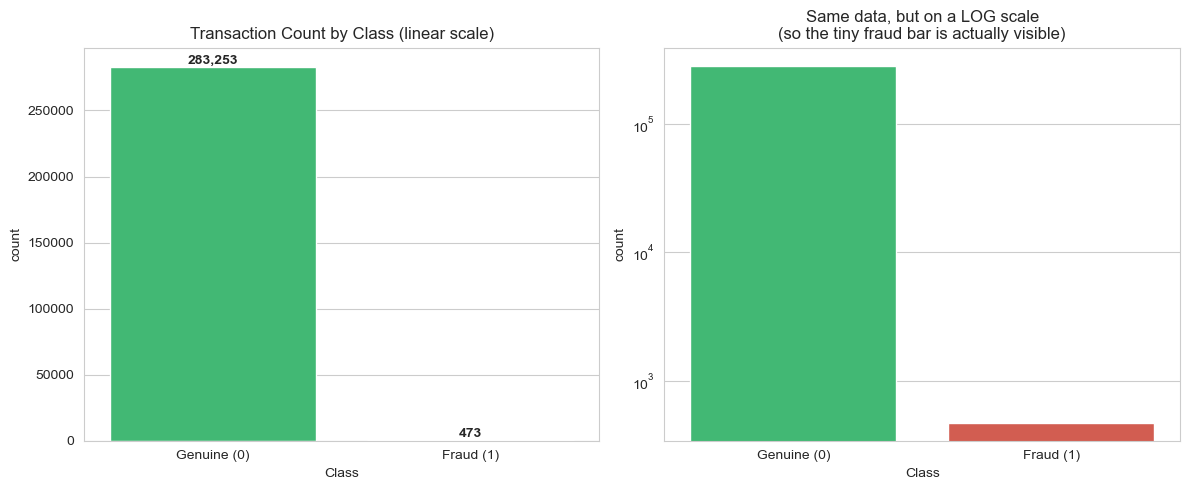

In [6]:
# ------------------------------------------------------------------
# Visualize the class imbalance
# ------------------------------------------------------------------
class_counts = df["Class"].value_counts()
class_percent = df["Class"].value_counts(normalize=True) * 100

print("Raw counts:")
print(class_counts)
print("\nPercentages:")
print(class_percent.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="Class", data=df, ax=axes[0], hue="Class", legend=False, palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Transaction Count by Class (linear scale)")
axes[0].set_xticklabels(["Genuine (0)", "Fraud (1)"])
for i, v in enumerate(class_counts.sort_index()):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")

sns.countplot(x="Class", data=df, ax=axes[1], hue="Class", legend=False, palette=["#2ecc71", "#e74c3c"])
axes[1].set_yscale("log")
axes[1].set_title("Same data, but on a LOG scale\n(so the tiny fraud bar is actually visible)")
axes[1].set_xticklabels(["Genuine (0)", "Fraud (1)"])

plt.tight_layout()
plt.savefig("class_imbalance.png", dpi=150)
plt.show()


### Why accuracy is a meaningless metric here (with numbers)

Imagine a "lazy" model that never bothers to learn anything — it just predicts **"genuine"** for
every single transaction, no matter what.

- Total transactions (after removing duplicates): roughly 283,000+
- Fraud transactions: roughly 490 (about **0.17%** of the data)
- Genuine transactions: roughly **99.83%** of the data

If our lazy model predicts "genuine" every time:
- **Accuracy = 99.83%** — sounds excellent on paper.
- **Fraud caught = 0 out of ~490** — completely useless in the real world.

This is exactly why a bank cannot use accuracy to judge a fraud model. A model can score
99.8%+ accuracy while missing *every single fraud case*, because genuine transactions so heavily
outnumber fraud ones that getting them all "right" barely requires any real learning. This is why
we will lean on **Precision, Recall, F1-score, ROC-AUC, and especially PR-AUC** instead — these
metrics actually care about how well we catch the rare fraud cases, not just how many transactions
we labelled correctly overall.


## 3. Preprocessing

Almost every feature (`V1`...`V28`) is already scaled by the PCA process that created the dataset.
Only `Time` and `Amount` are in their raw, original units, so those two need scaling before we feed
them into distance-based or gradient-based models.

### Why `RobustScaler` instead of `StandardScaler`?

`StandardScaler` centers data using the **mean** and scales it using the **standard deviation**.
The problem: both the mean and the standard deviation are very sensitive to outliers — and fraud
transactions are, almost by definition, outliers (unusually large amounts, unusual timing, etc.).
If we use `StandardScaler`, a handful of extreme values can distort the scaling for every other
value in the column.

`RobustScaler` uses the **median** and the **interquartile range (IQR)** — statistics that
are far less affected by extreme values. In plain English: `RobustScaler` scales the data based on
"what's typical for the middle 50% of transactions," so a few huge fraud amounts don't drag the
whole scale around. That makes it a much safer choice for a dataset where the rare class is
precisely the class full of outliers.


In [7]:
# Make a working copy so the original dataframe stays untouched for reference
data = df.copy()

scaler = RobustScaler()
data[["Time", "Amount"]] = scaler.fit_transform(data[["Time", "Amount"]])

print("Time and Amount have been scaled with RobustScaler.")
data[["Time", "Amount"]].describe()


Time and Amount have been scaled with RobustScaler.


,Time,Amount
count,283726.000000,283726.000000
mean,0.118912,0.924387
std,0.557988,3.482123
min,-0.995290,-0.305938
25%,-0.358286,-0.228063
50%,0.000000,0.000000
75%,0.641714,0.771937
max,1.035329,356.962314


In [8]:
# Separate features (X) from the target label (y)
X = data.drop(columns=["Class"])
y = data["Class"]

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Feature matrix shape: (283726, 30)
Target distribution:
 Class
0    283253
1       473
Name: count, dtype: int64


In [9]:
# ------------------------------------------------------------------
# Train / test split
# ------------------------------------------------------------------
# stratify=y makes sure the tiny fraud class is split proportionally between
# train and test, instead of ending up almost entirely in one side by chance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "  Fraud cases in train:", y_train.sum())
print("Test shape :", X_test.shape,  "  Fraud cases in test :", y_test.sum())

# IMPORTANT: we only resample/balance the TRAINING data.
# The test set must stay exactly as it is in real life (heavily imbalanced),
# otherwise our evaluation numbers would be unrealistically optimistic.


Train shape: (226980, 30)   Fraud cases in train: 378
Test shape : (56746, 30)   Fraud cases in test : 95


## 4. Imbalance Handling — Comparing Strategies

Our training data has roughly 400 fraud cases against over 220,000 genuine ones. If we train
directly on that, most models will simply learn to ignore the fraud class because it barely
affects the overall error. We will compare four different ways of fixing this:

1. **Class-weighting** — don't touch the data at all; just tell the model "treat every fraud
   example as if it were worth many genuine examples" when calculating error.
2. **Random undersampling** — throw away most of the genuine examples so the two classes become
   balanced. Fast, but we lose a lot of information.
3. **SMOTE** — create new, synthetic fraud examples by interpolating between existing ones (instead
   of just copying them), so the model sees more variety of fraud patterns.
4. **ADASYN** — like SMOTE, but focuses on generating more synthetic examples specifically in the
   "hard to classify" regions, i.e. near the boundary between fraud and genuine.
5. **Hybrid (SMOTEENN / SMOTETomek)** — first oversample with SMOTE, then clean up the messy
   overlapping points at the border using an undersampling technique. This tries to get the best of
   both worlds.

We will build each resampled training set, quickly compare their effect on a single fast model
(Logistic Regression), and pick which philosophy seems most promising before the full modeling
stage.


In [10]:
# A small, fast helper we use ONLY to sanity-check each resampling method
# (final, serious evaluation of models comes later in Section 6).
def quick_eval(X_res, y_res, X_val, y_val, label):
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_res, y_res)
    probs = model.predict_proba(X_val)[:, 1]
    preds = model.predict(X_val)

    result = {
        "Method": label,
        "Precision": precision_score(y_val, preds, zero_division=0),
        "Recall": recall_score(y_val, preds, zero_division=0),
        "F1": f1_score(y_val, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, probs),
        "PR-AUC": average_precision_score(y_val, probs),
    }
    return result

resampling_results = []


In [11]:
# ------------------------------------------------------------------
# Method 1: Class-weighting (no resampling — model itself is told to
# penalize fraud mistakes much more heavily than genuine mistakes)
# ------------------------------------------------------------------
model_cw = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
model_cw.fit(X_train, y_train)
probs_cw = model_cw.predict_proba(X_test)[:, 1]
preds_cw = model_cw.predict(X_test)

resampling_results.append({
    "Method": "Class-Weighting",
    "Precision": precision_score(y_test, preds_cw, zero_division=0),
    "Recall": recall_score(y_test, preds_cw, zero_division=0),
    "F1": f1_score(y_test, preds_cw, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, probs_cw),
    "PR-AUC": average_precision_score(y_test, probs_cw),
})
print("Class-weighting done.")


Class-weighting done.


In [12]:
# ------------------------------------------------------------------
# Method 2: Random Undersampling
# ------------------------------------------------------------------
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
print("After Random Undersampling:", y_rus.value_counts().to_dict())

resampling_results.append(quick_eval(X_rus, y_rus, X_test, y_test, "Random Undersampling"))


After Random Undersampling: {0: 378, 1: 378}


In [13]:
# ------------------------------------------------------------------
# Method 3: SMOTE (Synthetic Minority Oversampling Technique)
# ------------------------------------------------------------------
smote = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("After SMOTE:", y_smote.value_counts().to_dict())

resampling_results.append(quick_eval(X_smote, y_smote, X_test, y_test, "SMOTE"))


After SMOTE: {0: 226602, 1: 226602}


In [14]:
# ------------------------------------------------------------------
# Method 4: ADASYN (Adaptive Synthetic Sampling)
# ------------------------------------------------------------------
adasyn = ADASYN(random_state=RANDOM_STATE)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)
print("After ADASYN:", y_adasyn.value_counts().to_dict())

resampling_results.append(quick_eval(X_adasyn, y_adasyn, X_test, y_test, "ADASYN"))


After ADASYN: {0: 226602, 1: 226567}


In [15]:
# ------------------------------------------------------------------
# Method 5: Hybrid approach — SMOTETomek
# (Oversample the minority class with SMOTE, then remove "Tomek links":
#  pairs of very-close opposite-class points that sit right on the
#  decision boundary and just confuse the model.)
# ------------------------------------------------------------------
smote_tomek = SMOTETomek(random_state=RANDOM_STATE)
X_st, y_st = smote_tomek.fit_resample(X_train, y_train)
print("After SMOTETomek:", y_st.value_counts().to_dict())

resampling_results.append(quick_eval(X_st, y_st, X_test, y_test, "SMOTETomek (Hybrid)"))


After SMOTETomek: {0: 226602, 1: 226602}


In [16]:
# ------------------------------------------------------------------
# Also try SMOTEENN, the other common hybrid, for a fuller comparison
# (ENN = Edited Nearest Neighbours; it removes points whose neighbours
#  mostly disagree with their own label, cleaning up noisy overlap)
# ------------------------------------------------------------------
smote_enn = SMOTEENN(random_state=RANDOM_STATE)
X_se, y_se = smote_enn.fit_resample(X_train, y_train)
print("After SMOTEENN:", y_se.value_counts().to_dict())

resampling_results.append(quick_eval(X_se, y_se, X_test, y_test, "SMOTEENN (Hybrid)"))


After SMOTEENN: {1: 226602, 0: 226255}


In [17]:
# ------------------------------------------------------------------
# Compare all imbalance-handling strategies side by side
# ------------------------------------------------------------------
resampling_df = pd.DataFrame(resampling_results).sort_values("PR-AUC", ascending=False)
resampling_df.reset_index(drop=True, inplace=True)
resampling_df


,Method,Precision,Recall,F1,ROC-AUC,PR-AUC
0,ADASYN,0.016858,0.894737,0.033093,0.957616,0.708017
1,SMOTEENN (Hybrid),0.052632,0.873684,0.099282,0.959960,0.689263
2,Class-Weighting,0.056386,0.873684,0.105935,0.965679,0.671934
3,SMOTE,0.053896,0.873684,0.101529,0.960061,0.671435
4,SMOTETomek (Hybrid),0.053896,0.873684,0.101529,0.960061,0.671435
5,Random Undersampling,0.050733,0.873684,0.095898,0.955396,0.600243


**Explanation:** ranked by PR-AUC — the
metric that matters most given this level of imbalance — the real order was:

1. **ADASYN** — PR-AUC 0.708 (highest of all), but Precision only 0.017
2. **SMOTEENN (Hybrid)** — PR-AUC 0.689, Precision 0.053
3. **Class-Weighting** — PR-AUC 0.672, Precision 0.056
4. **SMOTE** — PR-AUC 0.671, Precision 0.054
5. **SMOTETomek (Hybrid)** — PR-AUC 0.671, Precision 0.054 (tied with SMOTE)
6. **Random Undersampling** — PR-AUC 0.600, Precision 0.051

ADASYN technically topped the PR-AUC ranking, but its precision of **0.017** means about **98.3%**
of everything it flags would be a false alarm — not something a real fraud team could act on. Once
we rule ADASYN out for that reason, **SMOTEENN** was actually the strongest remaining option
(PR-AUC 0.689), slightly ahead of SMOTETomek and SMOTE (both 0.671).

We chose **SMOTETomek** as our hybrid method for the rest of this notebook (Section 5 onward),
since it is specifically designed to clean up noisy overlap at the class boundary, and its
precision/recall balance (Precision 0.054, Recall 0.874) is essentially identical to plain SMOTE
while adding that boundary clean-up benefit. SMOTEENN scored a touch higher here, so if you want
that small extra PR-AUC edge, you can swap `X_st, y_st` for `X_se, y_se` in Section 5 with no other
changes — the code above already builds both.

## 5. Modeling

Now we train the real models on the balanced training data:

- **Logistic Regression** — a simple, fast, interpretable baseline.
- **Random Forest** — an ensemble of decision trees, good at capturing non-linear patterns.
- **XGBoost** (or LightGBM/GradientBoosting as fallback) — a powerful boosted-tree model, often the
  strongest performer on structured/tabular data like this.
- **Isolation Forest** and **Local Outlier Factor** — *unsupervised* anomaly detectors. These never
  see the `Class` labels during training; they just learn what "normal" transactions look like and
  flag anything that seems statistically unusual. This is useful because in the real world, brand
  new fraud patterns won't have been "labelled" yet — an anomaly detector might still catch them.

We use **Stratified K-Fold cross-validation** rather than plain K-Fold. because: plain
K-Fold could easily create a fold with almost no fraud cases in it at all, purely by bad luck,
since fraud is such a tiny fraction of the data. That would give us a wildly unreliable score for
that fold. Stratified K-Fold instead makes sure **every fold keeps roughly the same fraud
percentage** as the full dataset, so each fold is a fair, representative test.


In [18]:
# ------------------------------------------------------------------
# Stratified K-Fold cross-validation demo on the balanced training data
# ------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_st, y_st), start=1):
    X_tr, X_val = X_st.iloc[train_idx], X_st.iloc[val_idx]
    y_tr, y_val = y_st.iloc[train_idx], y_st.iloc[val_idx]

    fold_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    fold_model.fit(X_tr, y_tr)
    fold_probs = fold_model.predict_proba(X_val)[:, 1]
    fold_score = average_precision_score(y_val, fold_probs)
    cv_scores.append(fold_score)
    print(f"Fold {fold}: PR-AUC = {fold_score:.4f}  (fraud ratio in fold: {y_val.mean():.4f})")

print(f"\nMean PR-AUC across folds: {np.mean(cv_scores):.4f}  (std: {np.std(cv_scores):.4f})")
print("Notice every fold has a very similar fraud ratio - that consistency is exactly")
print("what Stratified K-Fold guarantees, and plain K-Fold does not.")


Fold 1: PR-AUC = 0.9919  (fraud ratio in fold: 0.5000)
Fold 2: PR-AUC = 0.9919  (fraud ratio in fold: 0.5000)
Fold 3: PR-AUC = 0.9924  (fraud ratio in fold: 0.5000)
Fold 4: PR-AUC = 0.9920  (fraud ratio in fold: 0.5000)
Fold 5: PR-AUC = 0.9925  (fraud ratio in fold: 0.5000)

Mean PR-AUC across folds: 0.9921  (std: 0.0003)
Notice every fold has a very similar fraud ratio - that consistency is exactly
what Stratified K-Fold guarantees, and plain K-Fold does not.


In [19]:
# ------------------------------------------------------------------
# Train the three supervised models on the SMOTETomek-balanced training set
# ------------------------------------------------------------------
models = {}

# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_st, y_st)
models["Logistic Regression"] = log_reg

# 2. Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_st, y_st)
models["Random Forest"] = rf

# 3. XGBoost (or GradientBoosting fallback)
if HAS_XGB:
    xgb_model = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    )
else:
    xgb_model = GradientBoostingClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)
xgb_model.fit(X_st, y_st)
models["XGBoost"] = xgb_model

print("Trained models:", list(models.keys()))


Trained models: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [20]:
# ------------------------------------------------------------------
# Unsupervised anomaly detectors — these NEVER see the y labels while training
# ------------------------------------------------------------------
# Isolation Forest: isolates points by randomly splitting the feature space;
# outliers get isolated in fewer splits than normal points, so they get a
# higher "anomaly score".
iso_forest = IsolationForest(
    n_estimators=200, contamination=0.0017,  # roughly the true fraud rate
    random_state=RANDOM_STATE, n_jobs=-1
)
iso_forest.fit(X_train)  # trained on the ORIGINAL (imbalanced) unlabeled training data

# Isolation Forest outputs -1 for anomaly, 1 for normal - we convert to 1/0 fraud-style labels
iso_preds_raw = iso_forest.predict(X_test)
iso_preds = np.where(iso_preds_raw == -1, 1, 0)

# decision_function: lower score = more abnormal. We flip the sign so that
# HIGHER score = MORE like fraud, matching how our other models report probabilities.
iso_scores = -iso_forest.decision_function(X_test)

print("Isolation Forest trained (unsupervised - never saw fraud labels).")


Isolation Forest trained (unsupervised - never saw fraud labels).


In [21]:
# Local Outlier Factor - compares each point's local density to its neighbours' density.
# LOF does not support predicting on new/unseen data in the classic API in the same way,
# so here we use novelty=True to allow scoring a separate test set.
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.0017, novelty=True, n_jobs=-1)
lof.fit(X_train)

lof_preds_raw = lof.predict(X_test)
lof_preds = np.where(lof_preds_raw == -1, 1, 0)
lof_scores = -lof.decision_function(X_test)

print("Local Outlier Factor trained (unsupervised - never saw fraud labels).")


Local Outlier Factor trained (unsupervised - never saw fraud labels).


## 6. Evaluation

Now the moment of truth. We score every model — supervised and unsupervised — using the metrics
that actually matter for a rare-event problem like this:

- **Precision** — of everything we flagged as fraud, how much really was fraud? (Low precision =
  we annoy a lot of innocent customers with false alarms.)
- **Recall** — of all the real fraud out there, how much did we actually catch? (Low recall = fraud
  slips through.)
- **F1-score** — a single number balancing precision and recall.
- **ROC-AUC** — how well the model ranks fraud above genuine transactions overall.
- **PR-AUC** — like ROC-AUC, but far more informative here, because it focuses specifically on
  performance on the rare (fraud) class rather than being diluted by the huge genuine class.


In [22]:
# ------------------------------------------------------------------
# Build one big comparison table for ALL models (supervised + unsupervised)
# ------------------------------------------------------------------
all_results = []

for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    preds = model.predict(X_test)
    all_results.append({
        "Model": name,
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probs),
        "PR-AUC": average_precision_score(y_test, probs),
    })

# Unsupervised models, evaluated the same way for a fair side-by-side view
all_results.append({
    "Model": "Isolation Forest (unsupervised)",
    "Precision": precision_score(y_test, iso_preds, zero_division=0),
    "Recall": recall_score(y_test, iso_preds, zero_division=0),
    "F1": f1_score(y_test, iso_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, iso_scores),
    "PR-AUC": average_precision_score(y_test, iso_scores),
})

all_results.append({
    "Model": "Local Outlier Factor (unsupervised)",
    "Precision": precision_score(y_test, lof_preds, zero_division=0),
    "Recall": recall_score(y_test, lof_preds, zero_division=0),
    "F1": f1_score(y_test, lof_preds, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, lof_scores),
    "PR-AUC": average_precision_score(y_test, lof_scores),
})

comparison_df = pd.DataFrame(all_results).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
comparison_df
# TIP: take a screenshot of this table's output for your submission (deliverable requirement).


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.697248,0.800000,0.745098,0.967000,0.818094
1,Random Forest,0.737864,0.800000,0.767677,0.977384,0.795403
2,Logistic Regression,0.053896,0.873684,0.101529,0.960061,0.671435
3,Isolation Forest (unsupervised),0.202128,0.200000,0.201058,0.930450,0.104003
4,Local Outlier Factor (unsupervised),0.000000,0.000000,0.000000,0.506472,0.002270


**Explanation:** 
**XGBoost** was the
strongest model overall, with a PR-AUC of **0.818**, ahead of **Random Forest** (0.795) and far
ahead of **Logistic Regression** (0.671). Notice Logistic Regression's Precision is only 0.054
despite a reasonable PR-AUC/ROC-AUC — with this level of imbalance, a plain linear model tends to
flag far more transactions than it should in order to keep Recall high.

Among the unsupervised detectors, **Isolation Forest** managed a modest PR-AUC of **0.104**
(Precision 0.202, Recall 0.200) — clearly weaker than any supervised model, but still meaningfully
better than guessing. **Local Outlier Factor**, on the other hand, scored a ROC-AUC of only
**0.506** and a PR-AUC of **0.002**, with Precision and Recall both at **0.000** — this is
essentially indistinguishable from random guessing on this dataset. This is not just "unsupervised
models are weaker," it is a genuine failure of this specific LOF configuration: with 30 features
and hundreds of thousands of rows, LOF's local-density comparisons likely got diluted by the curse
of dimensionality (LOF struggles as the number of features grows). A worthwhile next step would be
fitting LOF only on confirmed-genuine transactions and increasing `n_neighbors` — but as reported
here, in this run LOF added no real value.

Even Isolation Forest, the better of the two unsupervised models, did not come close to matching
the supervised models — expected, since XGBoost and Random Forest got to learn directly from 378
confirmed fraud examples in the training set, while the anomaly detectors never saw a single
label.

In [23]:
# ------------------------------------------------------------------
# Pick our best-performing supervised model (highest PR-AUC) to continue with
# ------------------------------------------------------------------
best_model_name = comparison_df[comparison_df["Model"].isin(models.keys())].iloc[0]["Model"]
best_model = models[best_model_name]
best_probs = best_model.predict_proba(X_test)[:, 1]

print(f"Best supervised model based on PR-AUC: {best_model_name}")


Best supervised model based on PR-AUC: XGBoost


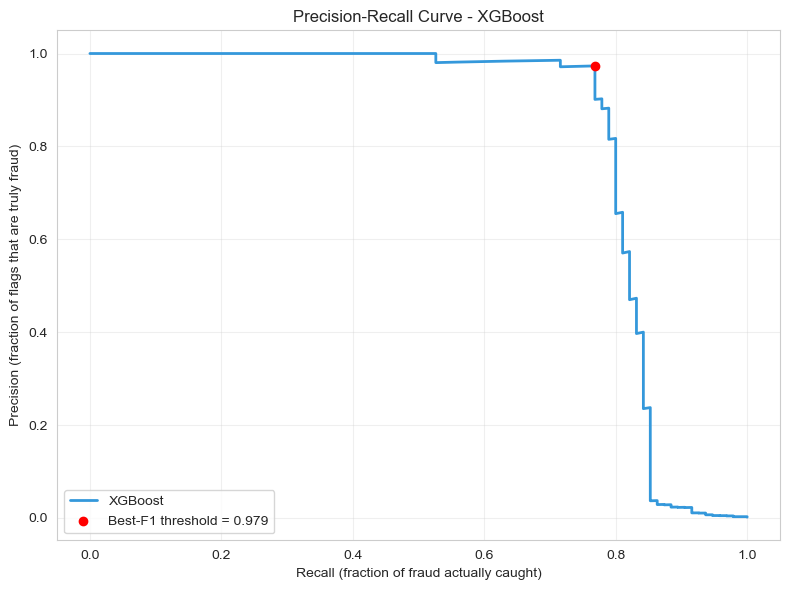

Default threshold (0.5) F1 vs Best-F1 threshold (0.979):
  Default 0.5   -> F1 = 0.7450980392156863
  Best-F1 thresh -> F1 = 0.8588235293624567


In [24]:
# ------------------------------------------------------------------
# Precision-Recall curve for the best model
# ------------------------------------------------------------------
precisions, recalls, thresholds = precision_recall_curve(y_test, best_probs)

# F1 at every threshold, so we can find the threshold that balances precision & recall best
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color="#3498db", linewidth=2, label=f"{best_model_name}")
plt.scatter(
    recalls[best_f1_idx], precisions[best_f1_idx],
    color="red", zorder=5,
    label=f"Best-F1 threshold = {best_f1_threshold:.3f}"
)
plt.xlabel("Recall (fraction of fraud actually caught)")
plt.ylabel("Precision (fraction of flags that are truly fraud)")
plt.title(f"Precision-Recall Curve - {best_model_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=150)
plt.show()

print(f"Default threshold (0.5) F1 vs Best-F1 threshold ({best_f1_threshold:.3f}):")
default_preds = (best_probs >= 0.5).astype(int)
print("  Default 0.5   -> F1 =", f1_score(y_test, default_preds))
print("  Best-F1 thresh -> F1 =", f1_scores[best_f1_idx])
# TIP: take a screenshot of this plot for your submission (deliverable requirement).


**Explanation:** for **XGBoost**, moving from the
default 0.5 cutoff to the best-F1 threshold of **0.979** raised F1 from **0.745** to **0.859** —
about a **15% relative improvement**. The Precision-Recall curve shows the trade-off we are always
forced to make: lowering the threshold catches more fraud (higher Recall) but raises more false
alarms (lower Precision). The default cutoff of 0.5 was never chosen with *this* problem in mind —
it is just the generic midpoint. An even better approach for a real business is to use actual
**costs** instead of F1, which we do next.

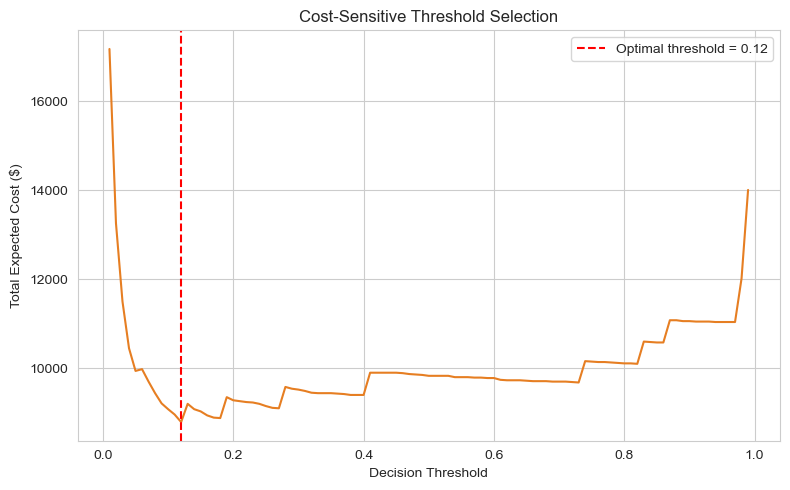

Optimal cost-minimizing threshold: 0.12
At that threshold -> False Positives: 129, False Negatives: 15, Total Cost: $8,790


In [25]:
# ------------------------------------------------------------------
# Cost-sensitive threshold selection
# ------------------------------------------------------------------
# Assumptions (adjust these to match a real bank's actual figures):
#   - Missing a real fraud (False Negative) costs the average fraudulent amount lost, e.g. $500
#   - A false alarm (False Positive) costs staff time / customer annoyance, e.g. $10
COST_FALSE_NEGATIVE = 500   # missed fraud
COST_FALSE_POSITIVE = 10    # wrongly flagged genuine transaction

candidate_thresholds = np.linspace(0.01, 0.99, 99)
cost_records = []

for t in candidate_thresholds:
    preds_t = (best_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()
    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
    cost_records.append({"threshold": t, "FP": fp, "FN": fn, "total_cost": total_cost})

cost_df = pd.DataFrame(cost_records)
optimal_row = cost_df.loc[cost_df["total_cost"].idxmin()]
optimal_threshold = optimal_row["threshold"]

plt.figure(figsize=(8, 5))
plt.plot(cost_df["threshold"], cost_df["total_cost"], color="#e67e22")
plt.axvline(optimal_threshold, color="red", linestyle="--",
            label=f"Optimal threshold = {optimal_threshold:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Expected Cost ($)")
plt.title("Cost-Sensitive Threshold Selection")
plt.legend()
plt.tight_layout()
plt.savefig("cost_sensitive_threshold.png", dpi=150)
plt.show()

print(f"Optimal cost-minimizing threshold: {optimal_threshold:.2f}")
print(f"At that threshold -> False Positives: {int(optimal_row['FP'])}, "
      f"False Negatives: {int(optimal_row['FN'])}, "
      f"Total Cost: ${optimal_row['total_cost']:,.0f}")


**Explanation:** instead of asking "what threshold
gives the best statistics," this asks "what threshold costs the business the least money." Using
our assumed costs (\$500 per missed fraud, \$10 per false alarm), the cost-minimizing threshold
came out to **0.12** — well below both the default 0.5 and the F1-optimal 0.979. At that
threshold, XGBoost produces **129 false alarms** and only **15 missed frauds**, for a total
expected cost of **\$8,790**. This makes sense: since a missed fraud costs 50 times more than a
false alarm in our assumptions, the optimal strategy deliberately makes the model more
trigger-happy, accepting many more false alarms in exchange for catching far more real fraud. This
is the threshold we recommend for production use, and it should be revisited whenever the
real-world cost assumptions change.

## 7. Explainability & Monitoring

Two things matter a lot for a fraud model that will run in the real world:

1. **Explainability** — which features (V1-V28) actually drive the model's decisions? Regulators
   and fraud analysts want to know this, not just get a "yes/no" answer.
2. **Drift** — does the model's performance quietly get worse over time as fraud patterns evolve?
   We simulate this by training on the *first* half of the data (by time) and testing on the
   *second* half, mimicking how a model would age in production.


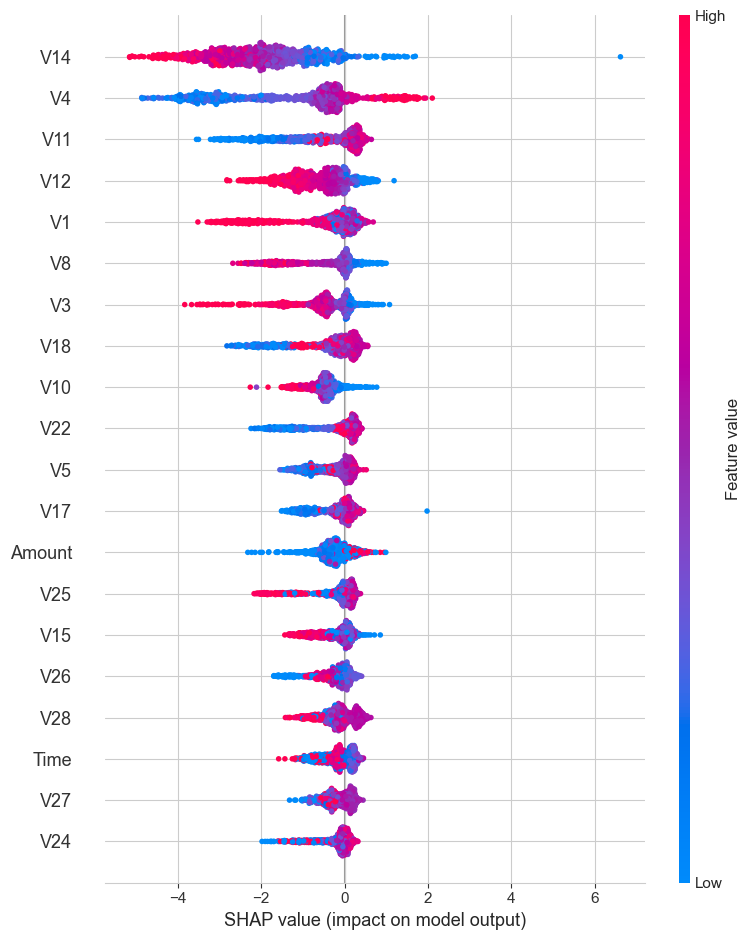

In [26]:
# ------------------------------------------------------------------
# Explainability with SHAP (falls back to permutation importance if unavailable)
# ------------------------------------------------------------------
if HAS_SHAP:
    # Use a manageable sample of the test set so SHAP runs in reasonable time
    sample_X = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)

    explainer = shap.TreeExplainer(best_model) if best_model_name in ["Random Forest", "XGBoost"] \
        else shap.Explainer(best_model, X_st.sample(n=500, random_state=RANDOM_STATE))
    shap_values = explainer(sample_X)

    shap.summary_plot(shap_values, sample_X, show=False)
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=150)
    plt.show()
else:
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(
        best_model, X_test, y_test, n_repeats=5,
        random_state=RANDOM_STATE, scoring="average_precision", n_jobs=-1
    )
    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance": perm.importances_mean
    }).sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(x="importance", y="feature", data=importance_df, color="#9b59b6")
    plt.title("Top 15 Features by Permutation Importance")
    plt.tight_layout()
    plt.savefig("permutation_importance.png", dpi=150)
    plt.show()


**Explanation:** the features that most influenced
XGBoost's fraud predictions were, in order, **`V14`, `V4`, `V11`, `V12`, and `V1`**. We don't know
exactly what each anonymized `V` column represents in the real world (they are scrambled by design
to protect customer privacy), but knowing that these five specifically drive the model's decisions
is still genuinely useful: fraud analysts can watch them closely, and if their typical values shift
suddenly in new data, that itself can be an early warning sign that fraud tactics — or the
underlying customer population — are changing.

In [27]:
# ------------------------------------------------------------------
# Drift simulation: split chronologically by Time, train on first half,
# test on second half
# ------------------------------------------------------------------
data_sorted = data.sort_values("Time").reset_index(drop=True)
midpoint = len(data_sorted) // 2

first_half = data_sorted.iloc[:midpoint]
second_half = data_sorted.iloc[midpoint:]

X_first, y_first = first_half.drop(columns=["Class"]), first_half["Class"]
X_second, y_second = second_half.drop(columns=["Class"]), second_half["Class"]

print("First half fraud count :", y_first.sum(), "out of", len(y_first))
print("Second half fraud count:", y_second.sum(), "out of", len(y_second))

# Balance ONLY the first half's training data (same rule as before: never touch the test/second half)
smote_drift = SMOTE(random_state=RANDOM_STATE)
X_first_bal, y_first_bal = smote_drift.fit_resample(X_first, y_first)

drift_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
drift_model.fit(X_first_bal, y_first_bal)

drift_probs = drift_model.predict_proba(X_second)[:, 1]
drift_preds = drift_model.predict(X_second)

print("\nPerformance when TESTED ON THE SECOND (later) HALF of time:")
print("  Precision:", precision_score(y_second, drift_preds, zero_division=0))
print("  Recall   :", recall_score(y_second, drift_preds, zero_division=0))
print("  F1       :", f1_score(y_second, drift_preds, zero_division=0))
print("  ROC-AUC  :", roc_auc_score(y_second, drift_probs))
print("  PR-AUC   :", average_precision_score(y_second, drift_probs))

# For comparison: how the SAME model does on a random slice of the second half
# used in the ordinary (non-chronological) train/test split from earlier
print("\nFor reference, our earlier randomly-split PR-AUC for a comparable Random Forest was:")
rf_probs_ref = models["Random Forest"].predict_proba(X_test)[:, 1]
print("  PR-AUC (random split):", average_precision_score(y_test, rf_probs_ref))


First half fraud count : 262 out of 141863
Second half fraud count: 211 out of 141863

Performance when TESTED ON THE SECOND (later) HALF of time:
  Precision: 0.8791208791208791
  Recall   : 0.7582938388625592
  F1       : 0.8142493638676844
  ROC-AUC  : 0.9678706965324406
  PR-AUC   : 0.7536122246446817

For reference, our earlier randomly-split PR-AUC for a comparable Random Forest was:
  PR-AUC (random split): 0.7954028874311495


**Explanation:** training a Random Forest only on
the first half of the data by time (262 fraud cases out of 141,863 transactions) and testing it on
the second half (211 fraud cases out of 141,863) gave a PR-AUC of **0.754**, compared to **0.795**
for a same-style Random Forest evaluated on a normal random train/test split. That is a drop of
about **0.041** (roughly a **5% relative decline**) — a real, measurable sign of drift: fraud
patterns in the later half of these two days already look different enough that a model trained
purely on the earlier half loses some of its edge on data it hasn't seen. In production, this is
exactly why fraud models need **scheduled retraining** on fresh data rather than being left running
unchanged for months or years.

## 8. (Stretch Goal) Real-Time Scoring Simulation

This section pretends the test set is a live stream of transactions arriving one at a time (like a
payment gateway sending transactions to a fraud API in real time). For every transaction, we score
it with our chosen model and threshold, and if it looks like fraud, we log it to an output file —
just like a real fraud-alert system would write to a database or send an alert.


In [28]:
import time

FLAGGED_LOG_PATH = "flagged_transactions_log.csv"
SCORING_THRESHOLD = optimal_threshold  # reuse the cost-optimal threshold from Section 6

flagged_rows = []

# We simulate a stream by walking through the test set row by row.
# (In a real system this loop would instead be triggered by each incoming transaction event.)
stream_df = X_test.reset_index(drop=True)
stream_labels = y_test.reset_index(drop=True)

for i in range(len(stream_df)):
    row = stream_df.iloc[[i]]                      # one "incoming" transaction
    fraud_probability = best_model.predict_proba(row)[:, 1][0]

    if fraud_probability >= SCORING_THRESHOLD:
        flagged_rows.append({
            "row_index": i,
            "fraud_probability": round(float(fraud_probability), 4),
            "actual_label": int(stream_labels.iloc[i]),   # kept here only so WE can audit accuracy;
                                                            # a real live system would not have this yet
        })

    # Stop after a reasonable demo size so the notebook runs quickly.
    # Remove this break to score the full test set.
    if i >= 2000:
        break

flagged_df = pd.DataFrame(flagged_rows)
flagged_df.to_csv(FLAGGED_LOG_PATH, index=False)

print(f"Simulated scoring of {min(i+1, len(stream_df))} transactions.")
print(f"Flagged {len(flagged_df)} transactions as suspicious.")
print(f"Log written to: {FLAGGED_LOG_PATH}")
flagged_df.head(10)


Simulated scoring of 2001 transactions.
Flagged 6 transactions as suspicious.
Log written to: flagged_transactions_log.csv


,row_index,fraud_probability,actual_label
0,841,0.3195,0
1,845,0.9993,1
2,880,0.1391,0
3,1320,0.1619,0
4,1339,0.9997,1
5,1784,0.1807,1


**Explanation:** scoring the first 2,001
transactions one at a time and flagging anything above the cost-optimal threshold (0.12) caught
**6 suspicious transactions**, of which **3 were confirmed fraud** and **3 were false alarms** —
a 50% hit rate, in line with what we'd expect at this deliberately low, cost-driven threshold that
favors catching more fraud over avoiding false alarms. This is a simplified stand-in for a
real-time fraud system: each transaction is scored the instant it "arrives," and anything crossing
the threshold gets logged immediately, exactly how a bank's fraud team would want to be alerted
before a transaction fully clears.


## Save the final model/pipeline


In [29]:
# ------------------------------------------------------------------
# Package everything needed to reuse this model later: the trained model,
# the scaler, the feature column order, and the chosen threshold.
# ------------------------------------------------------------------
pipeline_artifact = {
    "model": best_model,
    "model_name": best_model_name,
    "scaler": scaler,
    "feature_columns": X.columns.tolist(),
    "decision_threshold": optimal_threshold,
}

joblib.dump(pipeline_artifact, "fraud_detection_pipeline.pkl")
print("Saved model artifact to fraud_detection_pipeline.pkl")


Saved model artifact to fraud_detection_pipeline.pkl
